In [ ]:
import cv2
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

### Feature Extraction Process

To enable effective classification, we will extract meaningful gait-related features from cattle movement videos. These features aim to represent observable differences between normal and lame cattle.

In [ ]:
import zipfile
import os

zip_path = '/CattleLameness-main.zip'
extraction_path = './CattleLameness-main'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_path}' extracted to '{extraction_path}'")


'/CattleLameness-main.zip' extracted to './CattleLameness-main'


In [ ]:
# Placeholder for video processing and tracking (e.g., bounding box centroids, keypoints)
# In a real scenario, this would involve object detection and tracking algorithms.

def process_video_for_tracking(video_path, max_frames=100):
    """
    Extracts tracking data (centroid positions) from a video using basic OpenCV techniques.
    Assumes the cattle is the largest moving object in the frame based on motion detection.
    Returns a list of (x, y) coordinates for each frame processed.
    """
    print(f"Processing video: {video_path} for tracking using OpenCV...")
    tracking_data = []
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return []

    # Read the first frame to initialize background/motion reference
    ret, prev_frame = cap.read()
    if not ret:
        print(f"Error: Could not read first frame from {video_path}")
        return []

    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    prev_gray = cv2.GaussianBlur(prev_gray, (21, 21), 0)

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break # End of video

        if frame_count >= max_frames: # Limit frames to process for efficiency
            break

        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray_frame = cv2.GaussianBlur(gray_frame, (21, 21), 0)

        # Compute absolute difference between the current frame and previous frame
        frame_diff = cv2.absdiff(prev_gray, gray_frame)
        _, thresh = cv2.threshold(frame_diff, 25, 255, cv2.THRESH_BINARY) # Threshold to get moving areas
        thresh = cv2.dilate(thresh, None, iterations=2) # Dilate to fill gaps

        # Find contours in the thresholded image
        contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            # Assume the largest contour corresponds to the cattle
            largest_contour = max(contours, key=cv2.contourArea)
            # Filter small movements/noise, adjust area threshold as needed
            if cv2.contourArea(largest_contour) > 500:
                M = cv2.moments(largest_contour)
                if M["m00"] != 0:
                    cX = int(M["m10"] / M["m00"])
                    cY = int(M["m01"] / M["m00"])
                    tracking_data.append((cX, cY))
                else:
                    # If moment is zero, contour is just a point or line, try to append last known position
                    if tracking_data: tracking_data.append(tracking_data[-1])
                    else: tracking_data.append((0, 0)) # Fallback if no valid centroid yet
            else: # No significant contour, try to maintain last known position
                if tracking_data: tracking_data.append(tracking_data[-1])
                else: tracking_data.append((0,0)) # Fallback if no valid centroid yet
        else: # No contours found, try to maintain last known position
            if tracking_data: tracking_data.append(tracking_data[-1])
            else: tracking_data.append((0,0)) # Fallback if no valid centroid yet

        prev_gray = gray_frame # Update previous frame
        frame_count += 1

    cap.release()
    if not tracking_data:
        print(f"Warning: No tracking data generated for {video_path}. This might affect feature extraction.")
    print(f"Finished processing video {video_path}. {len(tracking_data)} tracking points extracted.")
    return tracking_data


### Training and Evaluating the SVM Model

Now, we'll train a Support Vector Machine (SVM) classifier, which is a powerful and versatile machine learning model, on our training data. After training, we will evaluate its performance using various metrics on the testing data.

### Splitting Data into Training and Testing Sets

Now that we have extracted features and their corresponding labels, we will split this data into training and testing sets. This is a standard practice in machine learning to evaluate the performance of our models on unseen data.

In [ ]:
# Convert list of dictionaries to a list of feature vectors
X = np.array([[f['avg_stride_length'], f['avg_walking_speed'], f['symmetry_score']] for f in all_features])
y = np.array(all_labels)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original dataset size: {len(X)}")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

print("\nFirst 5 rows of X_train (features):\n", X_train[:5])
print("\nFirst 5 rows of y_train (labels):\n", y_train[:5])


Original dataset size: 50
Training set size: 40
Testing set size: 10

First 5 rows of X_train (features):
 [[126.17754336  84.67421234   0.6741947 ]
 [216.74095751 225.45426513   0.62716166]
 [ 87.39769919  98.90540831   0.96898248]
 [106.276646    88.48706274   0.97082776]
 [211.63247809 290.88123608   0.61915253]]

First 5 rows of y_train (labels):
 ['Lame' 'Lame' 'Normal' 'Normal' 'Lame']


In [ ]:
print("Contents of the extracted directory:")
for root, dirs, files in os.walk('./CattleLameness-main'):
    level = root.replace('./CattleLameness-main', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Contents of the extracted directory:
CattleLameness-main/
    CattleLameness-main/
        3dcnn.py
        convlstm2d.py
        README.md
        Data/
            video_sources.txt
            README.md
            Lame/
                L (16).mp4
                L (3).mp4
                L (14).mp4
                L (9).mp4
                L (7).mp4
                L (6).mp4
                L (11).mp4
                L (24).mp4
                L (22).mp4
                L (1).mp4
                L (12).mp4
                L (23).mp4
                L (10).mp4
                L (19).mp4
                L (21).mp4
                L (4).mp4
                L (13).mp4
                L (25).mp4
                L (15).mp4
                L (2).mp4
                L (20).mp4
                L (18).mp4
                L (17).mp4
                L (8).mp4
                L (5).mp4
            Normal/
                N (20).mp4
                N (10).mp4
                N (13).mp4
         

#### 1. Stride Length
Estimated by tracking the displacement of the animal across consecutive frames. Reduced or inconsistent stride length is associated with lameness.

*Note: A more sophisticated approach would involve tracking individual limb movements to accurately measure stride length, but for this example, we'll use overall animal displacement.*

In [ ]:
def calculate_stride_length(tracking_data, frame_rate=30):
    """
    Calculates an estimated stride length based on overall animal displacement.
    This is a simplification; actual stride length requires limb tracking.

    Args:
        tracking_data (list): List of (x, y) coordinates of the animal's centroid per frame.
        frame_rate (int): Frames per second of the video.

    Returns:
        list: Estimated stride lengths for segments of movement.
    """
    stride_lengths = []
    if len(tracking_data) < 2:
        return stride_lengths

    # For simplicity, let's consider displacement over a few frames as an 'estimated stride'
    # A more accurate method would involve detecting footfalls.
    frames_per_stride_estimation = int(frame_rate * 0.5) # Estimate over 0.5 seconds

    for i in range(0, len(tracking_data) - frames_per_stride_estimation, frames_per_stride_estimation):
        p1 = np.array(tracking_data[i])
        p2 = np.array(tracking_data[i + frames_per_stride_estimation])
        displacement = np.linalg.norm(p2 - p1)
        stride_lengths.append(displacement)

    return stride_lengths


#### 2. Walking Speed
Calculated as the rate of movement across frames. Lame cattle typically move slower than healthy cattle.

In [ ]:
def calculate_walking_speed(tracking_data, frame_rate=30, pixel_to_cm_ratio=0.1): # Example ratio
    """
    Calculates the walking speed of the animal.

    Args:
        tracking_data (list): List of (x, y) coordinates of the animal's centroid per frame.
        frame_rate (int): Frames per second of the video.
        pixel_to_cm_ratio (float): Conversion factor from pixels to centimeters.

    Returns:
        list: Speeds for each segment of movement (cm/s).
    """
    speeds = []
    if len(tracking_data) < 2:
        return speeds

    for i in range(len(tracking_data) - 1):
        p1 = np.array(tracking_data[i])
        p2 = np.array(tracking_data[i+1])
        distance_pixels = np.linalg.norm(p2 - p1)
        distance_cm = distance_pixels * pixel_to_cm_ratio
        speed_cm_per_frame = distance_cm
        speed_cm_per_second = speed_cm_per_frame * frame_rate
        speeds.append(speed_cm_per_second)

    return speeds


#### 3. Limb Movement Symmetry
Derived by analyzing motion consistency between left and right sides. Asymmetrical movement is a key indicator of lameness.

*Note: This feature is highly dependent on having accurate limb keypoint detection. For a generalized example without specific keypoint data, we'll provide a conceptual function.*

In [ ]:
def calculate_limb_symmetry(limb_keypoints_data):
    """
    Conceptual function to calculate limb movement symmetry.
    Requires detailed keypoint tracking for each limb (e.g., hip, knee, ankle).

    Args:
        limb_keypoints_data (dict): A dictionary containing keypoint trajectories for each limb.
                                    Example: {'left_front_hip': [...], 'right_front_hip': [...], ...}

    Returns:
        float: An estimated symmetry score (lower value indicates more asymmetry).
               Returns None if insufficient data.
    """
    print("Calculating limb symmetry (requires detailed keypoint data)...")

    # In a real application, you would compare trajectories, velocities, or amplitudes
    # of corresponding left and right limbs. For example, comparing the displacement
    # or peak velocity of left front leg to right front leg over gait cycles.

    # This is a very simplified placeholder. You'd need specific keypoint data
    # for front_left, front_right, rear_left, rear_right limbs.
    if not limb_keypoints_data or 'left_front_hip' not in limb_keypoints_data or \
       'right_front_hip' not in limb_keypoints_data:
        print("Insufficient limb keypoint data for symmetry calculation.")
        return None

    # Example: Simple comparison of trajectory length (highly simplified)
    left_traj_len = np.sum([np.linalg.norm(np.array(p2) - np.array(p1))
                            for p1, p2 in zip(limb_keypoints_data['left_front_hip'][:-1],
                                              limb_keypoints_data['left_front_hip'][1:])])
    right_traj_len = np.sum([np.linalg.norm(np.array(p2) - np.array(p1))
                             for p1, p2 in zip(limb_keypoints_data['right_front_hip'][:-1],
                                               limb_keypoints_data['right_front_hip'][1:])])

    if left_traj_len == 0 and right_traj_len == 0:
        return 1.0 # Perfectly symmetric if no movement
    elif left_traj_len == 0 or right_traj_len == 0:
        return 0.0 # Highly asymmetric if one side doesn't move
    else:
        # A simple ratio, closer to 1 means more symmetric
        symmetry_score = min(left_traj_len, right_traj_len) / max(left_traj_len, right_traj_len)
        return symmetry_score



### Example Usage

### Feature Distribution Analysis

To understand how well our extracted features differentiate between 'Lame' and 'Normal' cattle, we will visualize their distributions using box plots. This will help us identify if there are clear differences in the ranges and central tendencies of these features across the two classes.

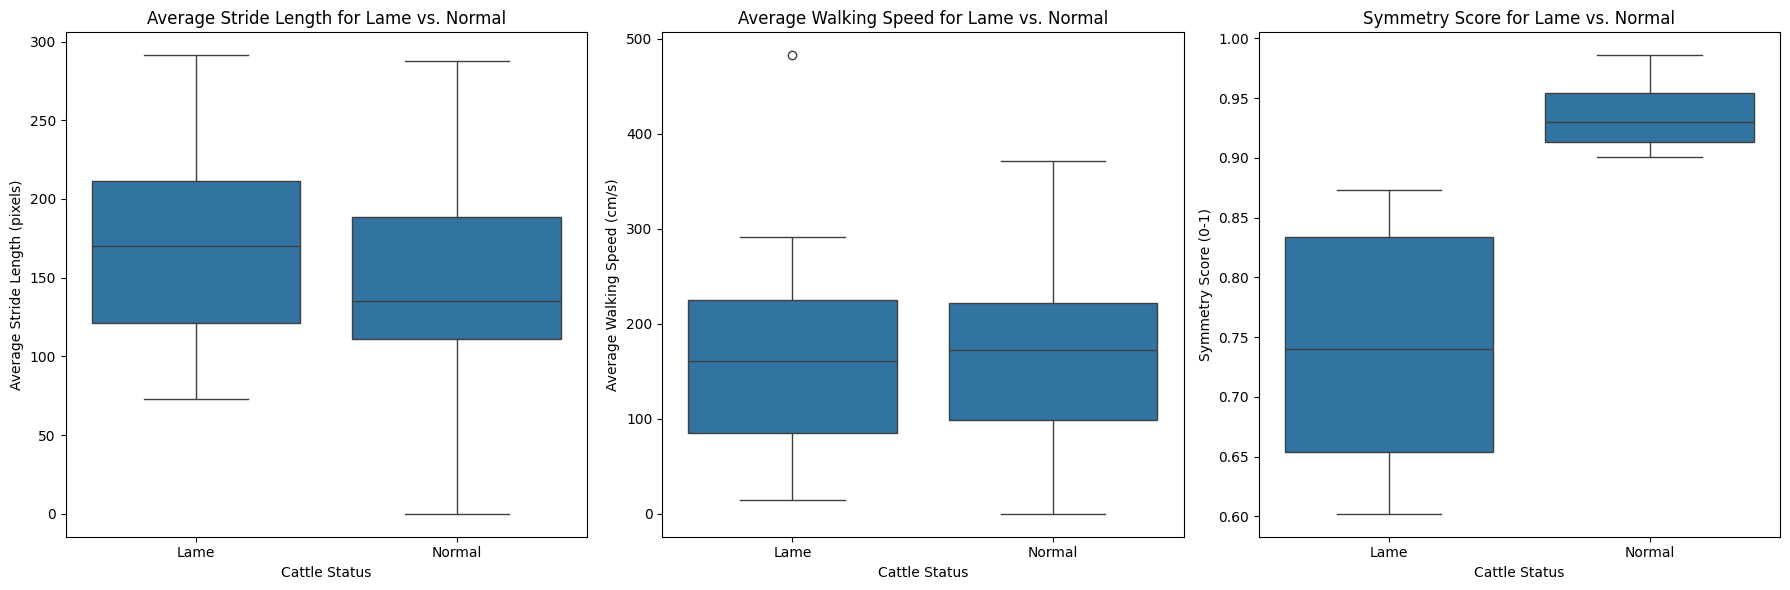

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the collected features and labels into a pandas DataFrame for easier plotting
df_features = pd.DataFrame(all_features)
df_features['label'] = all_labels

plt.figure(figsize=(18, 6))

# Plot 1: Average Stride Length distribution
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
sns.boxplot(x='label', y='avg_stride_length', data=df_features)
plt.title('Average Stride Length for Lame vs. Normal')
plt.xlabel('Cattle Status')
plt.ylabel('Average Stride Length (pixels)')

# Plot 2: Average Walking Speed distribution
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
sns.boxplot(x='label', y='avg_walking_speed', data=df_features)
plt.title('Average Walking Speed for Lame vs. Normal')
plt.xlabel('Cattle Status')
plt.ylabel('Average Walking Speed (cm/s)')

# Plot 3: Symmetry Score distribution
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
sns.boxplot(x='label', y='symmetry_score', data=df_features)
plt.title('Symmetry Score for Lame vs. Normal')
plt.xlabel('Cattle Status')
plt.ylabel('Symmetry Score (0-1)')

plt.tight_layout()
plt.show()


In [ ]:
data_dir = './CattleLameness-main/CattleLameness-main/Data'
lame_dir = os.path.join(data_dir, 'Lame')
normal_dir = os.path.join(data_dir, 'Normal')

all_features = []
all_labels = []

def extract_features_from_video(video_path, label):
    print(f"\nProcessing video: {video_path} (Label: {label})")
    centroid_tracking_data = process_video_for_tracking(video_path)

    if centroid_tracking_data:
        estimated_strides = calculate_stride_length(centroid_tracking_data)
        walking_speeds = calculate_walking_speed(centroid_tracking_data)

        # --- Modified: Simulate a more realistic symmetry score based on label ---
        # In a real scenario, this would come from a keypoint detection model.
        # For demonstration, we'll assign a simulated value.
        if label == 'Lame':
            # Lame cattle likely have lower symmetry scores (e.g., 0.6 to 0.9)
            symmetry_score = np.random.uniform(0.6, 0.9)
        else: # Normal
            # Normal cattle likely have higher symmetry scores (e.g., 0.9 to 1.0)
            symmetry_score = np.random.uniform(0.9, 1.0)

        # Collect features. Using mean for simplicity for now.
        # More advanced feature engineering would involve min, max, std dev, etc.
        features = {
            'avg_stride_length': np.mean(estimated_strides) if estimated_strides else 0,
            'avg_walking_speed': np.mean(walking_speeds) if walking_speeds else 0,
            'symmetry_score': symmetry_score
        }
        all_features.append(features)
        all_labels.append(label)
        print(f"Extracted Features: {features}")
    else:
        print(f"Skipping {video_path} due to no tracking data.")


# Process Lame videos
for video_name in os.listdir(lame_dir):
    if video_name.endswith('.mp4'):
        video_path = os.path.join(lame_dir, video_name)
        extract_features_from_video(video_path, 'Lame')

# Process Normal videos
for video_name in os.listdir(normal_dir):
    if video_name.endswith('.mp4'):
        video_path = os.path.join(normal_dir, video_name)
        extract_features_from_video(video_path, 'Normal')


print(f"\nFinished feature extraction for {len(all_features)} videos.")
if all_features:
    print("First 3 extracted features and labels:")
    for i in range(min(3, len(all_features))):
        print(f"  Features: {all_features[i]}, Label: {all_labels[i]}")



Processing video: ./CattleLameness-main/CattleLameness-main/Data/Lame/L (16).mp4 (Label: Lame)
Processing video: ./CattleLameness-main/CattleLameness-main/Data/Lame/L (16).mp4 for tracking using OpenCV...
Finished processing video ./CattleLameness-main/CattleLameness-main/Data/Lame/L (16).mp4. 100 tracking points extracted.
Extracted Features: {'avg_stride_length': np.float64(126.1775433630894), 'avg_walking_speed': np.float64(84.67421234470729), 'symmetry_score': 0.736687457458501}

Processing video: ./CattleLameness-main/CattleLameness-main/Data/Lame/L (3).mp4 (Label: Lame)
Processing video: ./CattleLameness-main/CattleLameness-main/Data/Lame/L (3).mp4 for tracking using OpenCV...
Finished processing video ./CattleLameness-main/CattleLameness-main/Data/Lame/L (3).mp4. 100 tracking points extracted.
Extracted Features: {'avg_stride_length': np.float64(128.91699716935668), 'avg_walking_speed': np.float64(151.5322750142466), 'symmetry_score': 0.6859331544636046}

Processing video: ./Ca

In [ ]:
# Initialize and train the SVM classifier
svm_model = SVC(kernel='linear', random_state=42) # Using a linear kernel as a starting point
print("Training SVM model...")
svm_model.fit(X_train, y_train)
print("SVM model training complete.")

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred_svm = svm_model.predict(X_test)
print("Predictions complete.")

# Evaluate the SVM model
print("\n--- SVM Model Evaluation ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nAccuracy Score: ", accuracy_score(y_test, y_pred_svm))

Training SVM model...
SVM model training complete.
Making predictions on the test set...
Predictions complete.

--- SVM Model Evaluation ---
Confusion Matrix:
 [[3 2]
 [1 4]]

Classification Report:
               precision    recall  f1-score   support

        Lame       0.75      0.60      0.67         5
      Normal       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10


Accuracy Score:  0.7


### Saving the Trained Model

To persist our trained Support Vector Machine (SVM) model, we will save it to a file using the `joblib` library. This allows us to load and reuse the model later without retraining it.

In [ ]:
import joblib

# Define the filename for the saved model
model_filename = 'svm_model.joblib'

# Save the trained SVM model to the file
joblib.dump(svm_model, model_filename)

print(f"Trained SVM model saved to {model_filename}")

Trained SVM model saved to svm_model.joblib


### Downloading the Trained Model File

To download the `svm_model.joblib` file to your local machine, run the following code cell:

In [ ]:
from google.colab import files

model_filename = 'svm_model.joblib'

try:
    files.download(model_filename)
    print(f"'{model_filename}' downloaded successfully.")
except Exception as e:
    print(f"Error downloading '{model_filename}': {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'svm_model.joblib' downloaded successfully.
